In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("libraries loaded successfully")

libraries loaded successfully


In [4]:
import os 
os.listdir()

['.android',
 '.appletviewer',
 '.bash_history',
 '.cache',
 '.copilot',
 '.dbclient',
 '.docker',
 '.eclipse',
 '.gitconfig',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.Ld2VirtualBox',
 '.matplotlib',
 '.p2',
 '.streamlit',
 '.tooling',
 '.vscode',
 '01_Ecommerce_EDA.ipynb',
 '3D Objects',
 '3D Objects - Shortcut.lnk',
 'AI_VEDIO_DUBBING',
 'AppData',
 'Application Data',
 'assu',
 'battery-report.html',
 'Contacts',
 'Cookies',
 'd1.ipynb',
 'Desktop',
 'Documents',
 'Downloads',
 'eclipse',
 'eclipse-workspace',
 'Favorites',
 'first progra.ipynb',
 'IBA_IOAPDATA',
 'import pandas.py',
 'IntelGraphicsProfiles',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'NetHood',
 'New folder',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{9193ddc4-a784-11f1-b2b9-be556de74348}.TM.blf',
 'NTUSER.DAT{9193ddc4-a784-11f1-b2b9-be556de74348}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{9193ddc4-a784-11f1-b2b9-be556de74348}.TMContainer

In [5]:
import pandas as pd

path = r"C:\Users\aswan\Downloads\Ecommerce_project"

orders = pd.read_csv(path + r"\olist_orders_dataset.csv")
customers = pd.read_csv(path + r"\olist_customers_dataset.csv")
order_items = pd.read_csv(path + r"\olist_order_items_dataset.csv")
products = pd.read_csv(path + r"\olist_products_dataset.csv")
payments = pd.read_csv(path + r"\olist_order_payments_dataset.csv")
reviews = pd.read_csv(path + r"\olist_order_reviews_dataset.csv")
sellers = pd.read_csv(path + r"\olist_sellers_dataset.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


In [6]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Sellers:", sellers.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Products: (32951, 9)
Payments: (103886, 5)
Reviews: (99224, 7)
Sellers: (3095, 4)


In [7]:
# Check missing values

print("ORDERS")
print(orders.isnull().sum())

print("\nCUSTOMERS")
print(customers.isnull().sum())

print("\nPRODUCTS")
print(products.isnull().sum())

print("\nPAYMENTS")
print(payments.isnull().sum())

print("\nREVIEWS")
print(reviews.isnull().sum())

ORDERS
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

CUSTOMERS
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

PRODUCTS
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

PAYMENTS
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

REVIEWS
review_id  

In [8]:
# Convert date columns to datetime

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')


# Fill missing product categories
products['product_category_name'] = products['product_category_name'].fillna('unknown')


# Create delivery days
orders['delivery_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.days


# Create estimated delivery delay
orders['delivery_delay'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.days


# Create order month
orders['order_month'] = (
    orders['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)


# Create late delivery flag
orders['is_late'] = (
    orders['delivery_delay'] > 0
).astype(int)


print("Data cleaning and feature engineering completed!")

Data cleaning and feature engineering completed!


In [9]:
# Overall Business KPIs

total_orders = orders['order_id'].nunique()
total_customers = customers['customer_unique_id'].nunique()
total_revenue = payments['payment_value'].sum()
average_order_value = total_revenue / total_orders

print("Total Orders:", total_orders)
print("Unique Customers:", total_customers)
print("Total Revenue:", round(total_revenue, 2))
print("Average Order Value:", round(average_order_value, 2))

Total Orders: 99441
Unique Customers: 96096
Total Revenue: 16008872.12
Average Order Value: 160.99


In [10]:
# Monthly Orders & Revenue Trend

monthly_orders = (
    orders.groupby('order_month')['order_id']
    .nunique()
    .reset_index(name='orders')
)

order_revenue = (
    payments.groupby('order_id')['payment_value']
    .sum()
    .reset_index()
)

monthly_revenue = (
    orders[['order_id', 'order_month']]
    .merge(order_revenue, on='order_id', how='left')
    .groupby('order_month')['payment_value']
    .sum()
    .reset_index(name='revenue')
)

monthly_sales = monthly_orders.merge(monthly_revenue, on='order_month')

monthly_sales

,order_month,orders,revenue
0,2016-09,4,252.24
1,2016-10,324,59090.48
2,2016-12,1,19.62
3,2017-01,800,138488.04
4,2017-02,1780,291908.01
5,2017-03,2682,449863.60
6,2017-04,2404,417788.03
7,2017-05,3700,592918.82
8,2017-06,3245,511276.38
9,2017-07,4026,592382.92


In [11]:
# Top 10 Product Categories by Revenue

category_sales = (
    order_items
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .groupby('product_category_name')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(category_sales)

product_category_name
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: price, dtype: float64


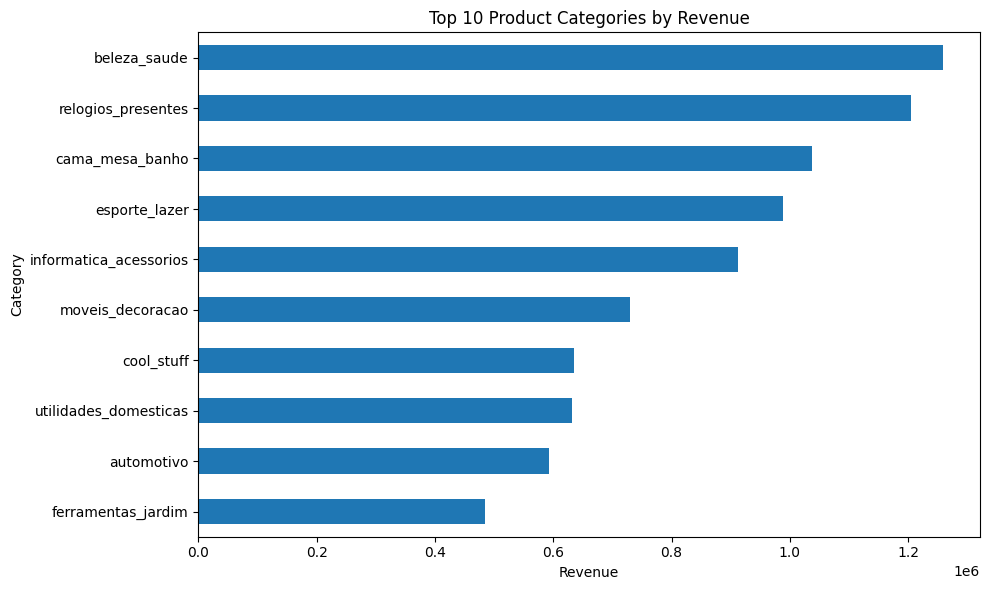

In [12]:
plt.figure(figsize=(10,6))

category_sales.sort_values().plot(kind='barh')

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [13]:
# Delivery Performance

delivered_orders = orders[orders['delivery_days'].notna()].copy()

avg_delivery_days = delivered_orders['delivery_days'].mean()

late_delivery_pct = (
    delivered_orders['is_late'].mean() * 100
)

print("Average Delivery Days:", round(avg_delivery_days, 2))
print("Late Delivery %:", round(late_delivery_pct, 2))

Average Delivery Days: 12.09
Late Delivery %: 6.77


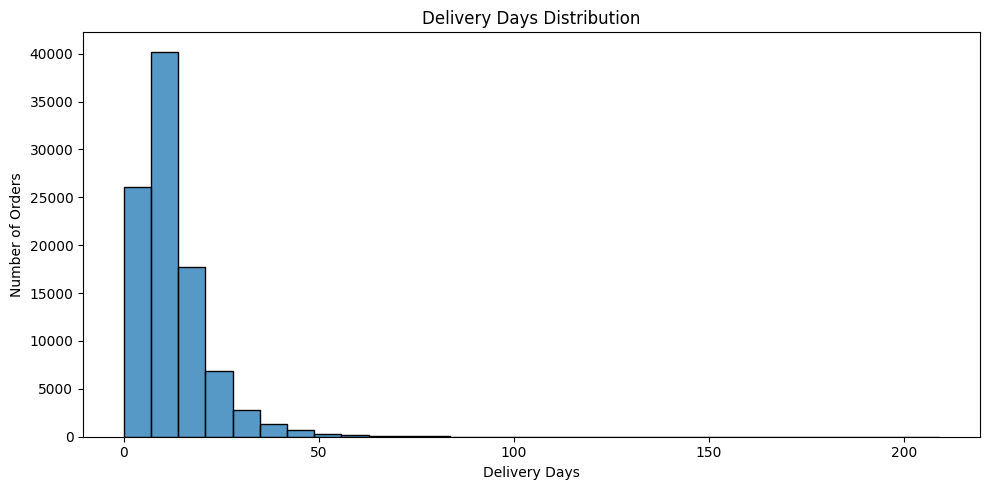

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    delivered_orders['delivery_days'],
    bins=30
)

plt.title('Delivery Days Distribution')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

In [15]:
# Review Score Distribution

review_counts = (
    reviews['review_score']
    .value_counts()
    .sort_index()
)

print(review_counts)

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


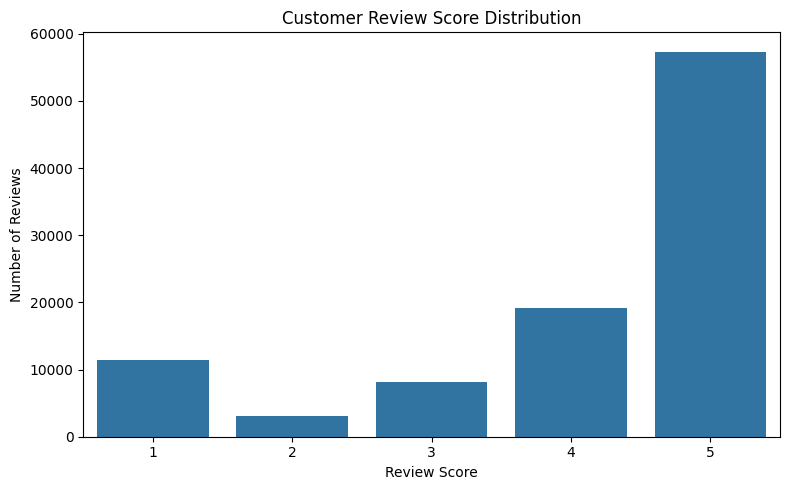

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=review_counts.index,
    y=review_counts.values
)

plt.title('Customer Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

In [17]:
delivery_reviews = (
    orders[['order_id', 'delivery_days', 'is_late']]
    .merge(
        reviews[['order_id', 'review_score']],
        on='order_id',
        how='inner'
    )
)

print(
    delivery_reviews.groupby('is_late')['review_score']
    .mean()
)

is_late
0    4.211789
1    2.271139
Name: review_score, dtype: float64


In [18]:
# Repeat Customer Analysis

customer_orders = (
    orders
    .merge(
        customers[['customer_id', 'customer_unique_id']],
        on='customer_id',
        how='left'
    )
    .groupby('customer_unique_id')['order_id']
    .nunique()
)

repeat_customers = (customer_orders > 1).sum()
one_time_customers = (customer_orders == 1).sum()

print("One-time Customers:", one_time_customers)
print("Repeat Customers:", repeat_customers)
print("Repeat Customer %:", round(
    repeat_customers / len(customer_orders) * 100, 2
))

One-time Customers: 93099
Repeat Customers: 2997
Repeat Customer %: 3.12


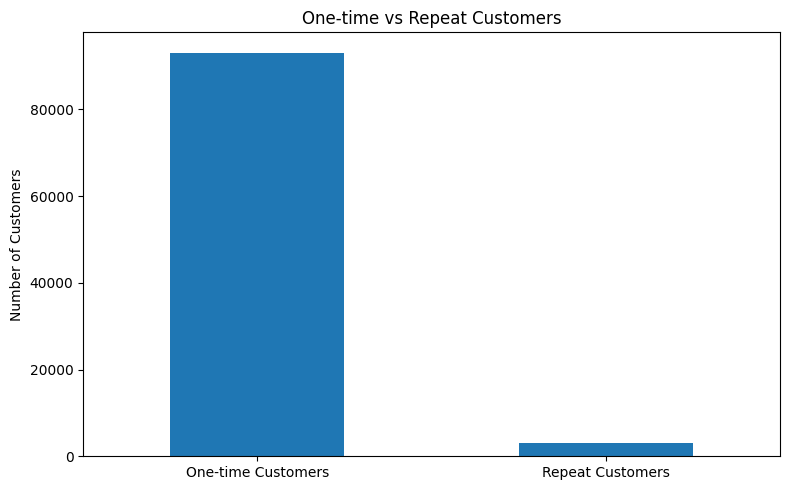

In [19]:
customer_type = pd.Series({
    'One-time Customers': one_time_customers,
    'Repeat Customers': repeat_customers
})

customer_type.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('One-time vs Repeat Customers')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
# Export cleaned data for Power BI

orders.to_csv(
    r"C:\Users\aswan\Downloads\Ecommerce_project\clean_orders.csv",
    index=False
)

print("Clean orders exported successfully!")

Clean orders exported successfully!
